# Tutorial 1 — Reading and Steering Concepts Inside a CNN

**Companion notebook, Part 1 of 2.** Released to attendees after the talk.

This notebook is a *proof-of-concept walkthrough* of the activation-space half of the
talk: finding **linear concept directions** inside a trained network, verifying they are
**causally used** (not just decodable), **steering** the network by writing to them, and
**erasing** a shortcut concept the network latched onto.

The pipeline mirrors:

- Klerings et al., *Steering Language Models in Multi-Token Generation: A Case Study on
  Tense and Aspect*, EMNLP 2025 — LDA-based concept directions + additive steering.
- Kim et al., *Interpretability Beyond Feature Attribution* (TCAV), ICML 2018 — concept
  activation vectors for image classifiers.

**Important framing.** Everything here runs on a *synthetic toy dataset* (geometric
shapes with texture and watermark overlays), NOT real scientific data, and the CNN is
deliberately tiny and briefly trained. The point is that every step — probe, direction,
causal test, steering curve, erasure — is the same code you would run on a real
classifier (e.g. an astronomical morphology classifier, where "watermark" becomes
"instrument signature" and "stripes" becomes a texture concept). Numbers are real
outputs of this notebook; only the *domain* is fake.

Runs on GPU when available, CPU otherwise.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}"
      + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

device: cuda (NVIDIA GeForce RTX 5070)


## 1. A synthetic dataset with classes, a concept, and a planted shortcut

Images are 32×32 grayscale. Three **classes** (the analog of morphology labels):

- `disk` — a filled blob,
- `ring` — an annulus,
- `cross` — a plus-shaped bar pattern.

Two **concepts** that vary independently of class:

- `stripes` — a sinusoidal texture overlay (a benign, real image property),
- `watermark` — a small bright corner patch (the planted *shortcut*: think
  "instrument signature").

**The trap we set for the model:** in the *training* set the watermark co-occurs with
`ring` 95% of the time (and only 5% with the other classes). In the *deconfounded* test
set the watermark appears on 50% of images of every class. A model that uses the
watermark as a ring-detector will look great on iid data and fail on deconfounded data —
exactly the cross-survey failure mode in the astronomy story.

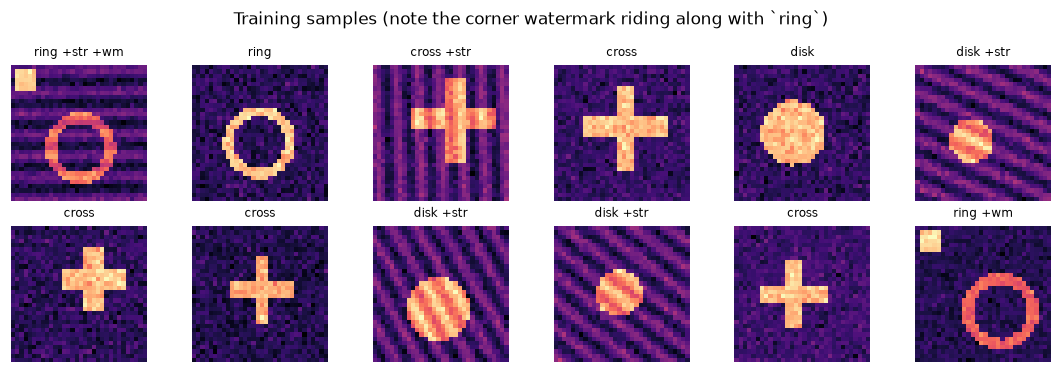

In [2]:
IMG = 32
yy, xx = np.mgrid[0:IMG, 0:IMG].astype(np.float32)


def draw_shape(cls: int, rng: np.random.Generator) -> np.ndarray:
    cy, cx = rng.uniform(12, 20, size=2)
    d = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    if cls == 0:  # disk
        r = rng.uniform(5.0, 8.0)
        img = (d < r).astype(np.float32)
    elif cls == 1:  # ring
        r = rng.uniform(6.0, 9.0)
        img = ((d < r) & (d > r - 2.5)).astype(np.float32)
    else:  # cross
        w = rng.uniform(1.5, 2.5)
        half = rng.uniform(7.0, 10.0)
        box = (np.abs(yy - cy) < half) & (np.abs(xx - cx) < half)
        img = (((np.abs(yy - cy) < w) | (np.abs(xx - cx) < w)) & box).astype(np.float32)
    return img


def make_dataset(n: int, p_wm_ring: float, p_wm_other: float, seed: int):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, 1, IMG, IMG), dtype=np.float32)
    y = rng.integers(0, 3, size=n)
    stripes = rng.random(n) < 0.5
    wm_prob = np.where(y == 1, p_wm_ring, p_wm_other)
    wm = rng.random(n) < wm_prob
    for i in range(n):
        img = draw_shape(int(y[i]), rng)
        if stripes[i]:
            theta = rng.uniform(0, np.pi)
            phase = rng.uniform(0, 2 * np.pi)
            img = img + 0.25 * np.sin(
                2 * np.pi * (xx * np.cos(theta) + yy * np.sin(theta)) / 5.0 + phase
            )
        if wm[i]:
            img[1:6, 1:6] = 1.5
        img = img + rng.normal(0, 0.08, size=img.shape)
        X[i, 0] = img
    return (
        torch.from_numpy(X).to(device),
        torch.from_numpy(y.astype(np.int64)).to(device),
        torch.from_numpy(stripes).to(device),
        torch.from_numpy(wm).to(device),
    )


# Training data: watermark spuriously correlated with `ring`.
Xtr, ytr, str_tr, wm_tr = make_dataset(6000, p_wm_ring=0.95, p_wm_other=0.05, seed=1)
# Confounded test set: same distribution as training.
Xte_c, yte_c, str_te_c, wm_te_c = make_dataset(2000, 0.95, 0.05, seed=2)
# Deconfounded test set: watermark independent of class (50% everywhere).
Xte_d, yte_d, str_te_d, wm_te_d = make_dataset(2000, 0.5, 0.5, seed=3)

CLASS_NAMES = ["disk", "ring", "cross"]
fig, axs = plt.subplots(2, 6, figsize=(10, 3.4))
for a, idx in zip(axs.flat, range(12)):
    a.imshow(Xtr[idx, 0].cpu(), cmap="magma")
    a.set_title(
        f"{CLASS_NAMES[ytr[idx]]}"
        f"{' +str' if str_tr[idx] else ''}{' +wm' if wm_tr[idx] else ''}",
        fontsize=8,
    )
    a.axis("off")
fig.suptitle("Training samples (note the corner watermark riding along with `ring`)")
fig.tight_layout()
plt.show()

## 2. A small CNN, briefly trained

Three conv blocks + global average pooling + a linear head. We train for a few epochs
only — enough for the shortcut to be learned and the demonstrations to work. In a real
release you would train to convergence; nothing downstream changes.

In [3]:
class SmallCNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.head = nn.Linear(64, 3)

    def forward(self, x: torch.Tensor, return_acts: bool = False):
        h1 = F.relu(self.conv1(x))
        h2 = F.relu(self.conv2(h1))
        h3 = F.relu(self.conv3(h2))
        g = h3.mean(dim=(2, 3))
        logits = self.head(g)
        if return_acts:
            return logits, {"h1": h1, "h2": h2, "h3": h3}
        return logits


model = SmallCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs, B = 3, 128
for epoch in range(n_epochs):
    perm = torch.randperm(len(Xtr))
    for i in range(0, len(Xtr), B):
        idx = perm[i : i + B]
        loss = F.cross_entropy(model(Xtr[idx]), ytr[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
    with torch.no_grad():
        acc_c = (model(Xte_c).argmax(1) == yte_c).float().mean().item()
        acc_d = (model(Xte_d).argmax(1) == yte_d).float().mean().item()
    print(f"epoch {epoch}: confounded-test acc {acc_c:.3f} | deconfounded-test acc {acc_d:.3f}")

epoch 0: confounded-test acc 0.654 | deconfounded-test acc 0.506
epoch 1: confounded-test acc 0.836 | deconfounded-test acc 0.656
epoch 2: confounded-test acc 0.929 | deconfounded-test acc 0.684


The gap between the two test accuracies is the first hint of the shortcut. Let's see
*where* the model is fooled: how often a watermarked non-ring image gets called a ring.

In [4]:
with torch.no_grad():
    pred_d = model(Xte_d).argmax(1)
mask_trap = (yte_d != 1) & wm_te_d
ring_fp = (pred_d[mask_trap] == 1).float().mean().item()
print(f"P(predict ring | true class is NOT ring, watermark present) = {ring_fp:.3f}")
print(f"({int(mask_trap.sum())} such trap images in the deconfounded test set)")

P(predict ring | true class is NOT ring, watermark present) = 0.360
(642 such trap images in the deconfounded test set)


## 3. Hypothesis 1 — linear decodability: probing every layer

We extract activations (global-average-pooled to a vector per image) at each conv block
and fit two kinds of direction per concept:

- **LDA direction** `d = pinv(Cov) @ (mu_pos - mu_neg)` — the whitened direction that
  best *separates* the concept; we use it for probing (reading).
- **Mean-difference direction** `d = mu_pos - mu_neg` — the raw displacement the concept
  causes in activation space, in the model's own units; we will use it later for
  steering (writing). This mirrors the EMNLP paper's move of scaling the unit direction
  by the class-mean projection: a steering vector must carry the concept's *magnitude*,
  not just its orientation.

Crucially, directions are fit on the **deconfounded** split, where concept and class
vary independently — otherwise the "watermark direction" would secretly be a ring
direction.

probe accuracy stripes     : h1=1.000  h2=1.000  h3=0.998
probe accuracy watermark   : h1=0.991  h2=1.000  h3=0.999
probe accuracy class=ring  : h1=0.988  h2=0.989  h3=0.985


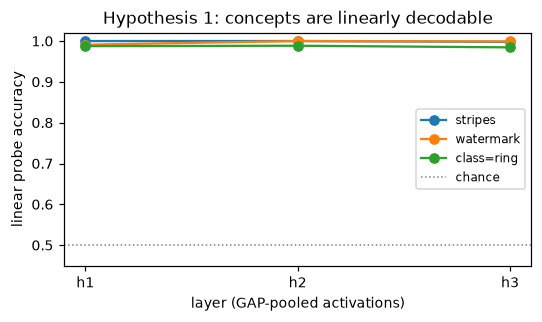

In [5]:
with torch.no_grad():
    _, acts_d = model(Xte_d, return_acts=True)
pooled = {k: v.mean(dim=(2, 3)) for k, v in acts_d.items()}


def lda_direction(X: torch.Tensor, labels: torch.Tensor):
    """Unit-norm LDA-style direction + held-in probe accuracy."""
    mu_p, mu_n = X[labels].mean(0), X[~labels].mean(0)
    cov = torch.cov(X.T)
    d = torch.linalg.pinv(cov) @ (mu_p - mu_n)
    d = d / d.norm()
    proj = X @ d
    thresh = 0.5 * (proj[labels].mean() + proj[~labels].mean())
    acc = ((proj > thresh) == labels).float().mean().item()
    return d, max(acc, 1 - acc)


def meandiff_direction(X: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    """Unit-norm difference of concept means — the model's own displacement axis."""
    d = X[labels].mean(0) - X[~labels].mean(0)
    return d / d.norm()


concepts = {
    "stripes": str_te_d,
    "watermark": wm_te_d,
    "class=ring": yte_d == 1,
}
probe_acc = {c: [] for c in concepts}
lda_dirs, md_dirs = {}, {}
for layer in ["h1", "h2", "h3"]:
    for cname, clabels in concepts.items():
        d, acc = lda_direction(pooled[layer], clabels)
        probe_acc[cname].append(acc)
        lda_dirs[(layer, cname)] = d
        md_dirs[(layer, cname)] = meandiff_direction(pooled[layer], clabels)

for cname, accs in probe_acc.items():
    print(f"probe accuracy {cname:12s}: " + "  ".join(
        f"{l}={a:.3f}" for l, a in zip(["h1", "h2", "h3"], accs)))

fig, ax = plt.subplots(figsize=(5, 3))
for cname, accs in probe_acc.items():
    ax.plot(["h1", "h2", "h3"], accs, marker="o", label=cname)
ax.axhline(0.5, color="gray", ls=":", lw=1, label="chance")
ax.set_ylim(0.45, 1.02)
ax.set_xlabel("layer (GAP-pooled activations)")
ax.set_ylabel("linear probe accuracy")
ax.set_title("Hypothesis 1: concepts are linearly decodable")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. The geometry: projecting activations onto concept directions

The scatter below is the toy analog of the paper's Figure 1: every test image's
penultimate activation vector, projected onto the (stripes, watermark) plane — the
separation is what the probes above are exploiting. Next to it, the cosine similarities
between the *mean-difference* directions at h2, which is the geometry that matters for
writing.

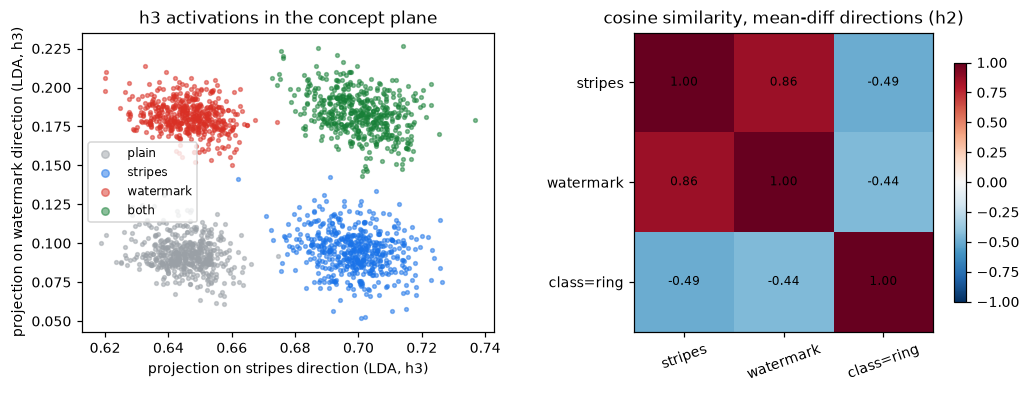

cos(watermark, class=ring) at h2: -0.439


In [6]:
d_str = lda_dirs[("h3", "stripes")]
d_wm3 = lda_dirs[("h3", "watermark")]
X3 = pooled["h3"]
px, py = (X3 @ d_str).cpu().numpy(), (X3 @ d_wm3).cpu().numpy()

fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.6))
groups = {
    "plain": (~str_te_d & ~wm_te_d, "#9aa0a6"),
    "stripes": (str_te_d & ~wm_te_d, "#1a73e8"),
    "watermark": (~str_te_d & wm_te_d, "#d93025"),
    "both": (str_te_d & wm_te_d, "#188038"),
}
for label, (m, color) in groups.items():
    m = m.cpu().numpy()
    axs[0].scatter(px[m], py[m], s=6, alpha=0.5, color=color, label=label)
axs[0].set_xlabel("projection on stripes direction (LDA, h3)")
axs[0].set_ylabel("projection on watermark direction (LDA, h3)")
axs[0].set_title("h3 activations in the concept plane")
axs[0].legend(fontsize=8, markerscale=2)

names = ["stripes", "watermark", "class=ring"]
D = torch.stack([md_dirs[("h2", n)] for n in names])
cos = (D @ D.T).cpu().numpy()
im = axs[1].imshow(cos, vmin=-1, vmax=1, cmap="RdBu_r")
axs[1].set_xticks(range(3), names, rotation=20)
axs[1].set_yticks(range(3), names)
for i in range(3):
    for j in range(3):
        axs[1].text(j, i, f"{cos[i, j]:.2f}", ha="center", va="center", fontsize=8)
axs[1].set_title("cosine similarity, mean-diff directions (h2)")
fig.colorbar(im, ax=axs[1], shrink=0.8)
fig.tight_layout()
plt.show()
print("cos(watermark, class=ring) at h2:", f"{cos[1, 2]:.3f}")

The watermark–ring entry is far from zero: the shortcut is visible *in the geometry* —
the model entangled the watermark with ring-ness during training. Stripes, the benign
concept, stays near-orthogonal to both. (Compare the paper's tense-vs-aspect cosine of
0.02.)

## 5. Hypothesis 2 — causal use: steering the classifier

Decodable is not the same as *used*. The causal test: during a forward pass, add
`alpha * direction` to the activations of an intermediate layer, broadcast across all
spatial positions (the image analog of "at every token"), and watch the prediction.
We steer **disk** images along the h2 **ring-class** mean-difference direction, sweeping
alpha in units of the typical activation norm at that layer — the paper's finding that
useful steering strength tracks activation norm is baked in here.

P(ring) on disk images: 0.001 (alpha=0) → 1.000 (alpha=1.0×‖h2‖)


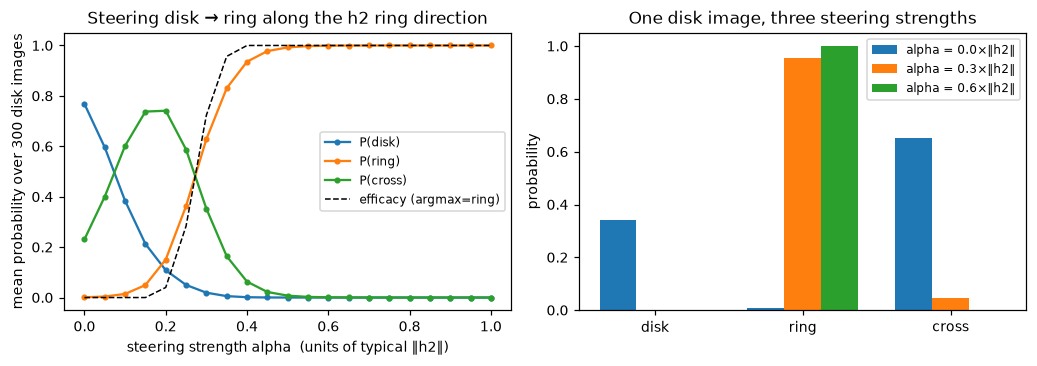

In [7]:
def steered_forward(x: torch.Tensor, layer: str, direction: torch.Tensor, alpha: float):
    """Forward pass with `alpha * direction` added to one layer's activations."""
    h1 = F.relu(model.conv1(x))
    h2 = F.relu(model.conv2(h1))
    if layer == "h1":
        h1 = h1 + alpha * direction[None, :, None, None]
        h2 = F.relu(model.conv2(h1))
    elif layer == "h2":
        h2 = h2 + alpha * direction[None, :, None, None]
    h3 = F.relu(model.conv3(h2))
    if layer == "h3":
        h3 = h3 + alpha * direction[None, :, None, None]
    return model.head(h3.mean(dim=(2, 3)))


d_ring_h2 = md_dirs[("h2", "class=ring")]
disk_imgs = Xte_d[(yte_d == 0) & ~wm_te_d][:300]
typical_norm = pooled["h2"].norm(dim=1).mean().item()
alphas = np.linspace(0, 1.0, 21) * typical_norm

probs, effs = [], []
with torch.no_grad():
    for a in alphas:
        p = F.softmax(steered_forward(disk_imgs, "h2", d_ring_h2, float(a)), dim=1)
        probs.append(p.mean(0).cpu().numpy())
        effs.append((p.argmax(1) == 1).float().mean().item())
probs = np.array(probs)
print(f"P(ring) on disk images: {probs[0, 1]:.3f} (alpha=0) → {probs[-1, 1]:.3f} (alpha=1.0×‖h2‖)")

fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.4))
for k, cname in enumerate(CLASS_NAMES):
    axs[0].plot(alphas / typical_norm, probs[:, k], marker=".", label=f"P({cname})")
axs[0].plot(alphas / typical_norm, effs, "k--", lw=1, label="efficacy (argmax=ring)")
axs[0].set_xlabel("steering strength alpha  (units of typical ‖h2‖)")
axs[0].set_ylabel("mean probability over 300 disk images")
axs[0].set_title("Steering disk → ring along the h2 ring direction")
axs[0].legend(fontsize=8)

demo = disk_imgs[:1]
bars_alphas = [0.0, 0.3 * typical_norm, 0.6 * typical_norm]
width = 0.25
with torch.no_grad():
    for j, a in enumerate(bars_alphas):
        p = F.softmax(steered_forward(demo, "h2", d_ring_h2, float(a)), dim=1)[0].cpu().numpy()
        axs[1].bar(np.arange(3) + (j - 1) * width, p, width,
                   label=f"alpha = {a / typical_norm:.1f}×‖h2‖")
axs[1].set_xticks(range(3), CLASS_NAMES)
axs[1].set_ylabel("probability")
axs[1].set_title("One disk image, three steering strengths")
axs[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

The dose–response curve is the causal verification: pushing activations along the
direction smoothly and monotonically transfers probability mass from `disk` to `ring`,
with full prediction flips well below one activation-norm of push. (Try the same sweep
with the *LDA* direction: it barely moves the output — a whitened direction is optimal
for reading but points partly along low-variance axes the model never uses, a nice
demonstration that *decoding direction ≠ steering direction*.)

## 6. The shortcut, caught red-handed — then surgically removed

Two final experiments with the **watermark** direction:

1. **Causal test of the shortcut:** steer along the watermark direction (not the ring
   direction!) and watch P(ring) rise. If the model merely *recorded* the watermark
   without using it, this would do nothing.
2. **Concept erasure:** neutralize the watermark coordinate at inference time and
   re-measure the deconfounded metrics.

For erasure we use **mean-ablation**, not zero-projection: every h2 spatial position's
component along the watermark direction is reset to the average value that coordinate
takes on *clean* images (a per-position baseline). Zeroing the coordinate outright
shoves activations off-manifold — post-ReLU activations have a large positive baseline
along almost any direction — and collateral damage destroys the ring class entirely
(hypothesis H3, additive intervenability, failing in real time; try it). Resetting to
the clean baseline removes exactly the watermark's *deviation* and nothing else.

P(ring) on disk images, steering along WATERMARK dir: 0.001 → 1.000


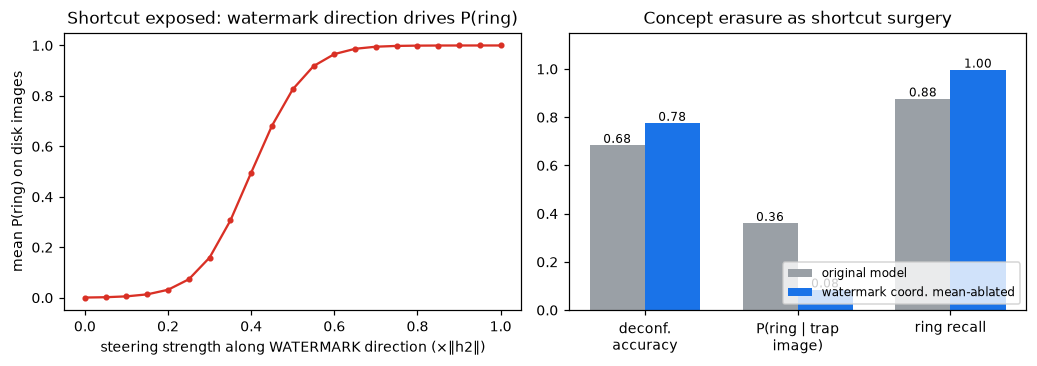

deconfounded accuracy:       0.684 → 0.775
ring FP rate on trap images: 0.360 → 0.084
ring recall (kept intact):   0.876 → 0.996


In [8]:
d_wm_h2 = md_dirs[("h2", "watermark")]

probs_wm = []
with torch.no_grad():
    for a in alphas:
        p = F.softmax(steered_forward(disk_imgs, "h2", d_wm_h2, float(a)), dim=1)
        probs_wm.append(p.mean(0)[1].item())
print(f"P(ring) on disk images, steering along WATERMARK dir: "
      f"{probs_wm[0]:.3f} → {probs_wm[-1]:.3f}")

# Per-spatial-position baseline of the watermark coordinate, from clean images only.
with torch.no_grad():
    h2_clean = acts_d["h2"][~wm_te_d]
    wm_baseline = torch.einsum("bchw,c->bhw", h2_clean, d_wm_h2).mean(0)  # [H, W]


def erased_forward(x: torch.Tensor, direction: torch.Tensor, base: torch.Tensor):
    """Forward pass with the direction's coordinate mean-ablated at every h2 position."""
    h1 = F.relu(model.conv1(x))
    h2 = F.relu(model.conv2(h1))
    coef = torch.einsum("bchw,c->bhw", h2, direction)
    h2 = h2 - (coef - base[None])[:, None] * direction[None, :, None, None]
    h3 = F.relu(model.conv3(h2))
    return model.head(h3.mean(dim=(2, 3)))


with torch.no_grad():
    pred_erased = erased_forward(Xte_d, d_wm_h2, wm_baseline).argmax(1)
acc_before = (pred_d == yte_d).float().mean().item()
acc_after = (pred_erased == yte_d).float().mean().item()
fp_before = ring_fp
fp_after = (pred_erased[mask_trap] == 1).float().mean().item()
rec_before = (pred_d[yte_d == 1] == 1).float().mean().item()
rec_after = (pred_erased[yte_d == 1] == 1).float().mean().item()

fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.4))
axs[0].plot(alphas / typical_norm, probs_wm, marker=".", color="#d93025")
axs[0].set_xlabel("steering strength along WATERMARK direction (×‖h2‖)")
axs[0].set_ylabel("mean P(ring) on disk images")
axs[0].set_title("Shortcut exposed: watermark direction drives P(ring)")

labels = ["deconf.\naccuracy", "P(ring | trap\nimage)", "ring recall"]
before = [acc_before, fp_before, rec_before]
after = [acc_after, fp_after, rec_after]
xpos = np.arange(3)
axs[1].bar(xpos - 0.18, before, 0.36, label="original model", color="#9aa0a6")
axs[1].bar(xpos + 0.18, after, 0.36, label="watermark coord. mean-ablated", color="#1a73e8")
axs[1].set_xticks(xpos, labels)
for x, v in zip(xpos - 0.18, before):
    axs[1].text(x, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
for x, v in zip(xpos + 0.18, after):
    axs[1].text(x, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
axs[1].set_ylim(0, 1.15)
axs[1].set_title("Concept erasure as shortcut surgery")
axs[1].legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

print(f"deconfounded accuracy:       {acc_before:.3f} → {acc_after:.3f}")
print(f"ring FP rate on trap images: {fp_before:.3f} → {fp_after:.3f}")
print(f"ring recall (kept intact):   {rec_before:.3f} → {rec_after:.3f}")

The surgery removes most of the shortcut (trap false-positives collapse) *without*
harming — in fact improving — genuine ring detection, and overall out-of-distribution
accuracy rises. All from one linear direction and no retraining.

## 7. Takeaways, and the checklist for your own model

On a ~25k-parameter CNN and a fake dataset, we ran the full activation-space program:

| Step in this notebook | Hypothesis it verifies |
|---|---|
| Layer-wise linear probes | **H1: linear decodability** — concepts are directions |
| Steering dose–response curve | **H2: causal use** — downstream layers read the direction |
| Mean-ablation vs. zero-projection | **H3: additive intervenability** — edits must stay on-manifold |
| Direction cosine matrix | **H4: selectivity** — and it *caught* the watermark↔ring entanglement |
| One direction working for all images | **H5: stable read–write location** |

The same five hypotheses — see the accompanying `operationalsteps.md` — are exactly what
you must re-verify on a real model before trusting any of these figures; none hold for
free outside toy-land. Two practical lessons that transfer directly: *whitened
directions read, raw displacement directions write*, and *ablate to the clean baseline,
not to zero*.

**References.** Klerings et al., EMNLP 2025 (`aclanthology.org/2025.emnlp-main.435`);
Kim et al., ICML 2018 (TCAV); Park et al., 2024 (categorical concept geometry).
Continue with **Tutorial 2**, which decomposes the *weights* instead of the activations.